In [1]:
import pandas as pd
df=pd.read_csv('hotel_bookings_data.csv')


In [2]:
df.head()
df.info()



<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 29 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_weekdays_nights        119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [3]:
missing=df.isnull().sum()
missing=missing[missing>0].sort_values(ascending=False)
missing_pct=(missing/len(df)*100).round(2)
pd.DataFrame({'missing':missing,'missing_pct':missing_pct})





,missing,missing_pct
company,112593,94.31
agent,16340,13.69
city,488,0.41
children,4,0.00


In [4]:
duplicate=df.duplicated().sum()
print(f"Duplicated rows:{duplicate:,}({duplicate/len(df)*100:.1f}%)")
df[df.duplicated(keep=False)].sort_values(list(df.columns)).head(6)




Duplicated rows:33,261(27.9%)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_weekdays_nights,adults,...,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status
78101,City Hotel,0,0,2017,December,40,2,0,2,1,...,2,No Deposit,NaN,NaN,0,Family,145.0,0,0,Check-Out
78104,City Hotel,0,0,2017,December,40,2,0,2,1,...,2,No Deposit,NaN,NaN,0,Family,145.0,0,0,Check-Out
78105,City Hotel,0,0,2017,December,40,2,0,2,1,...,2,No Deposit,NaN,NaN,0,Family,145.0,0,0,Check-Out
78403,City Hotel,0,0,2017,December,41,6,0,3,1,...,0,No Deposit,NaN,NaN,0,Personal,130.0,0,0,Check-Out
78407,City Hotel,0,0,2017,December,41,6,0,3,1,...,0,No Deposit,NaN,NaN,0,Personal,130.0,0,0,Check-Out
78385,City Hotel,0,0,2017,December,41,7,0,2,1,...,0,No Deposit,1.0,NaN,0,Family,119.0,0,0,Check-Out


In [5]:
df['meal'].value_counts(dropna=False)


meal
Breakfast     92310
Dinner        14463
No Meal       10650
Undefined      1169
Full Board      798
Name: count, dtype: int64

In [6]:
print(df['adr'].describe())
print(f"Negative ADR:{(df['adr']<0).sum()}")
print(f"Extreme ADR(>1000):{(df['adr']>1000).sum()}")
total_guests=df['adults']+df['children'].fillna(0)+df['babies']
print(f"Zero-guest bookings:{(total_guests==0).sum()}")


count    119390.000000
mean        101.831122
std          50.535790
min          -6.380000
25%          69.290000
50%          94.575000
75%         126.000000
max        5400.000000
Name: adr, dtype: float64
Negative ADR:1
Extreme ADR(>1000):1
Zero-guest bookings:180


In [8]:
clean=df.copy()
clean['booked via company']=clean['company'].notna().astype(int)
clean['booked via agent']=clean['agent'].notna().astype(int)
clean=clean.drop(columns=['company','agent'])
clean=clean.dropna(subset=['city'])
clean['children']=clean['children'].fillna(0)
clean=clean.drop_duplicates()
clean['meal']=clean['meal'].replace({'Undefined':'No Meal'})
clean=clean[(clean['adr']>=0)&(clean['adr']<=1000)]
clean['adr_is_zero']=(clean['adr']==0).astype(int)
clean['total_guests']=clean['adults']+clean['children']+clean['babies']
clean=clean[clean['total_guests']>0]
clean['total_nights']=clean['stays_in_weekend_nights']+clean['stays_in_weekdays_nights']
print(f"before :{len(df):,} after:{len(clean):,} Removed:{len(df)-len(clean):,}")


before :119,390 after:85,495 Removed:33,895


In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.rcParams['figure.dpi']=100


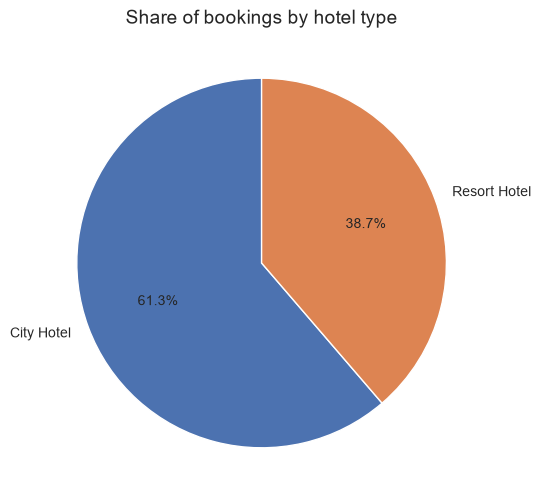

In [12]:
hotel_share=clean['hotel'].value_counts()
colors=['#4c72b0','#dd8452']
fig,ax=plt.subplots(figsize=(6,6))
ax.pie(hotel_share,labels=hotel_share.index,autopct='%1.1f%%',colors=colors,startangle=90)
ax.set_title('Share of bookings by hotel type',fontsize=14)
plt.show()


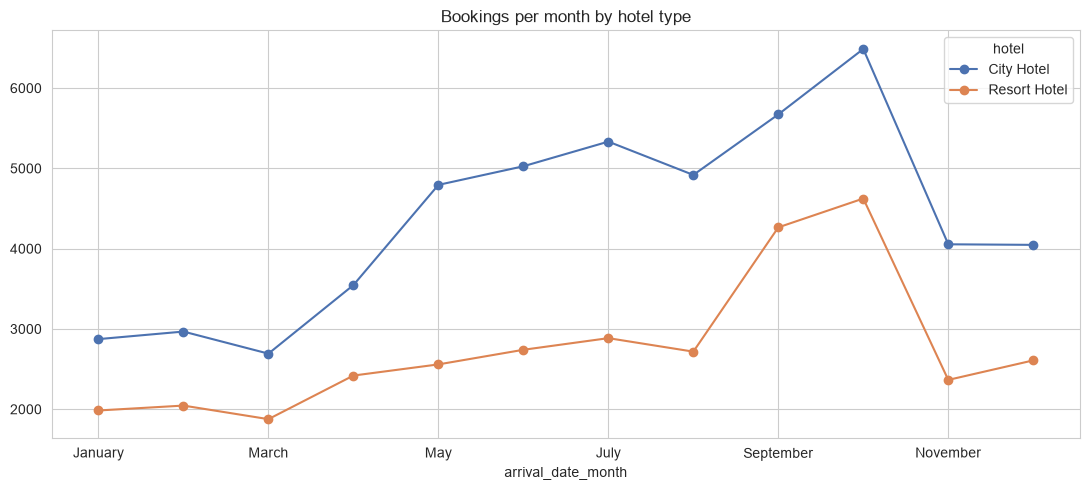

In [15]:
month_order=['January','February','March','April','May','June','July','August','September','October','November','December']
clean['arrival_date_month']=pd.Categorical(clean['arrival_date_month'],categories=month_order,ordered=True)
monthly=clean.groupby(['arrival_date_month','hotel'],observed=True).size().unstack()
fig,ax=plt.subplots(figsize=(11,5))
monthly.plot(kind='line',marker='o',ax=ax,color=colors)
ax.set_title('Bookings per month by hotel type')
plt.tight_layout()
plt.show()



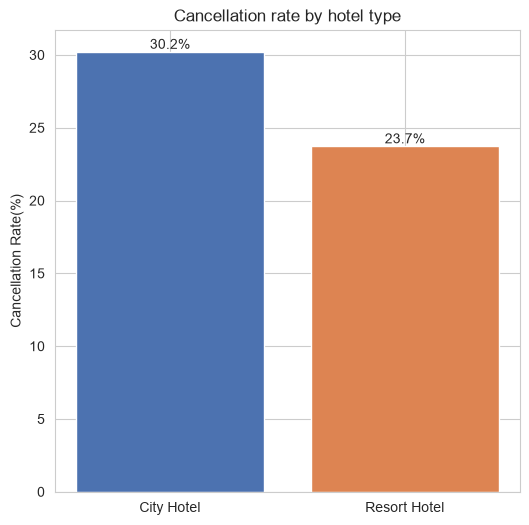

In [16]:
cancel_by_hotel=clean.groupby('hotel')['is_canceled'].mean()*100
fig,ax=plt.subplots(figsize=(6,6))
bars=ax.bar(cancel_by_hotel.index,cancel_by_hotel.values,color=colors)
ax.set_title('Cancellation rate by hotel type')
ax.set_ylabel('Cancellation Rate(%)')
for bar in bars:
    h=bar.get_height()
    ax.annotate(f'{h:.1f}%', (bar.get_x()+bar.get_width()/2, h), ha='center', va='bottom')
plt.show()

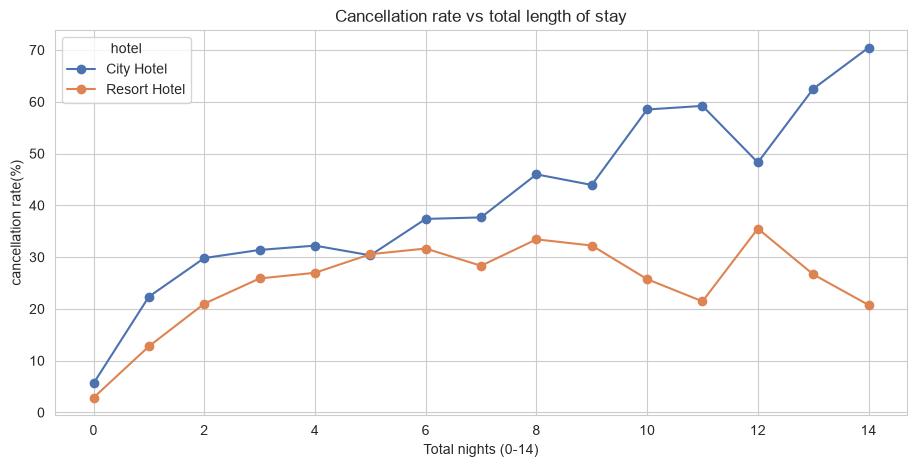

In [18]:
stay_df=clean[clean['total_nights'].between(0,14)]
stay_cancel=(stay_df.groupby(['total_nights','hotel'],observed=True)['is_canceled'].mean().mul(100).unstack())
fig,ax=plt.subplots(figsize=(11,5))
stay_cancel.plot(marker='o',ax=ax,color=colors)
ax.set_title('Cancellation rate vs total length of stay')
ax.set_xlabel('Total nights (0-14)')
ax.set_ylabel('cancellation rate(%)')
plt.show()

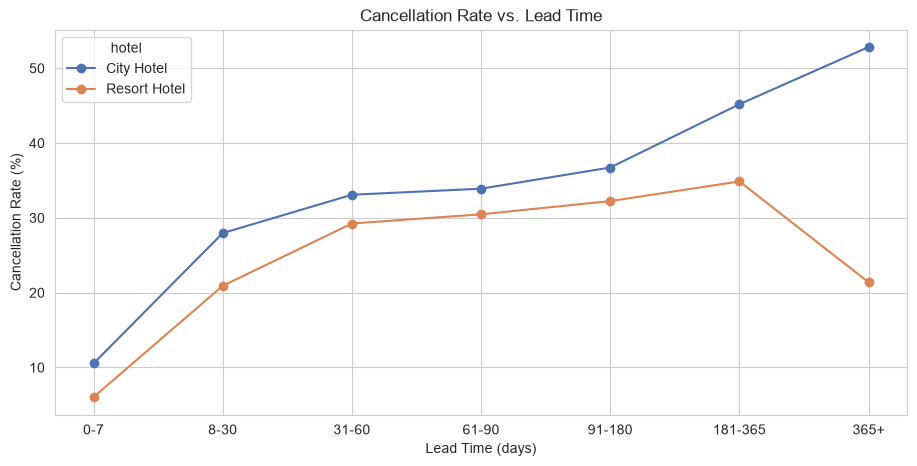

In [20]:
bins=[0,7,30,60,90,180,365,clean['lead_time'].max()+1]
labels=['0-7','8-30','31-60','61-90','91-180','181-365','365+']
clean['lead_time_bin'] = pd.cut(clean['lead_time'], bins=bins, labels=labels, include_lowest=True)

lead_cancel = (clean.groupby(['lead_time_bin', 'hotel'], observed=True)['is_canceled']
               .mean().mul(100).unstack())

fig, ax = plt.subplots(figsize=(11, 5))
lead_cancel.plot(marker='o', ax=ax, color=colors)
ax.set_title('Cancellation Rate vs. Lead Time')
ax.set_xlabel('Lead Time (days)')
ax.set_ylabel('Cancellation Rate (%)')
plt.show()
